# Estimated distributed PV (rooftop solar) — SWIS

AEMO's `distributed-pv-new-*` files carry a single 5-minute series: **estimated** generation from
behind-the-meter rooftop solar across the SWIS. It is a model output, not a meter reading — there is
no revenue metering behind the customer's meter for AEMO to add up — so treat it as AEMO's best
estimate rather than measured truth.

It is also the series that makes the demand notebook's headline possible. Operational demand is
*net* of rooftop PV, so every megawatt here is a megawatt that never appears as grid demand.

In [1]:
# Load Estimated Distributed PV (rooftop solar) Data
import sys
sys.path.insert(0, '../src')  # Add src directory to path (go up one level from notebooks/)
from wa_data import load_dpv, to_trading_intervals

# Load with explicit path (go up one level from notebooks/)
df = load_dpv(raw='../data/raw')

YEAR = 2025   # the year every slice and chart below follows

In [2]:
from IPython.display import display

display(df.head())
df.info()
display(df.describe())

,ts,dpv_mw
0,2023-10-01 08:00:00,415.39
1,2023-10-01 08:05:00,427.91
2,2023-10-01 08:10:00,460.49
3,2023-10-01 08:15:00,486.06
4,2023-10-01 08:20:00,493.67


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307007 entries, 0 to 307006
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   ts      307007 non-null  datetime64[ns]
 1   dpv_mw  307007 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.7 MB


,ts,dpv_mw
count,307007,307007.000000
mean,2025-03-17 07:55:14.004891392,486.698517
min,2023-10-01 08:00:00,0.000000
25%,2024-06-23 19:57:30,1.000000
50%,2025-03-17 07:55:00,9.070000
75%,2025-12-08 19:52:30,986.965000
max,2026-09-01 07:55:00,2321.210000
std,NaN,654.307515


In [3]:
df_agg = to_trading_intervals(df, ["dpv_mw"], ts="ts", how="mean")

In [4]:
display(df_agg.head())
df_agg.info()
display(df_agg.describe())

,ts,dpv_mw
0,2023-10-01 08:00:00,469.861667
1,2023-10-01 08:30:00,696.480000
2,2023-10-01 09:00:00,823.263333
3,2023-10-01 09:30:00,1160.718333
4,2023-10-01 10:00:00,1024.895000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51168 entries, 0 to 51167
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ts      51168 non-null  datetime64[ns]
 1   dpv_mw  51168 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 799.6 KB


,ts,dpv_mw
count,51168,51168.000000
mean,2025-03-17 07:44:59.999999744,486.701763
min,2023-10-01 08:00:00,0.020000
25%,2024-06-23 19:52:30,1.043333
50%,2025-03-17 07:45:00,11.182500
75%,2025-12-08 19:37:30,987.603333
max,2026-09-01 07:30:00,2313.165000
std,NaN,653.268814


In [5]:
# Slice the chosen year from the CONCATENATED frame — never from a single-year
# file, which is cut at 00:00 UTC (08:00 AWST) and so misses its own first
# 8 hours of January (they live in the previous year's file).
dyr = df_agg[df_agg.ts.dt.year == YEAR]

In [6]:
display(dyr.head())
dyr.info()
display(dyr.describe())

,ts,dpv_mw
21968,2025-01-01 00:00:00,0.09
21969,2025-01-01 00:30:00,0.09
21970,2025-01-01 01:00:00,0.09
21971,2025-01-01 01:30:00,0.09
21972,2025-01-01 02:00:00,0.09


<class 'pandas.core.frame.DataFrame'>
Index: 17520 entries, 21968 to 39487
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ts      17520 non-null  datetime64[ns]
 1   dpv_mw  17520 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 410.6 KB


,ts,dpv_mw
count,17520,17520.000000
mean,2025-07-02 11:45:00,489.791164
min,2025-01-01 00:00:00,0.020000
25%,2025-04-02 05:52:30,0.650000
50%,2025-07-02 11:45:00,11.394167
75%,2025-10-01 17:37:30,986.017500
max,2025-12-31 23:30:00,2083.158333
std,NaN,657.204961


## Visualisation

The same three views as the demand notebook, each solving the density problem a different way, plus
one that puts rooftop PV back next to the demand it hides:

1. **Average day by season** — collapses ~100k intervals into a mean day shape.
2. **One week at 5-minute resolution** — keeps the detail, narrows the window.
3. **Carpet plots** — every interval at once: position for time, colour for magnitude.
4. **Rooftop PV against grid demand** — why this series matters at all.

Set `YEAR` once in the next cell; everything below follows it.

In [7]:
# ── Chart setup: palette, shared theme, and derived frames ────────────────────────────────────────
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from wa_data import add_time_parts

# Categorical slots 1-3 of the reference palette, in fixed order (never cycled).
# Rooftop PV takes ORANGE throughout this notebook; demand keeps BLUE, as in the
# demand notebook. Colour follows the entity, not the chart.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

# Chart chrome, light surface
SURFACE, INK, INK_2, MUTED, GRID, AXIS = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7")

# Single-hue sequential ramps: orange for PV output, blue for volatility
RAMP_BLUE   = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
RAMP_ORANGE = ["#fde3d6", "#fbc7ae", "#f8a785", "#f2865c", "#eb6834", "#c9501f", "#73290c"]


def style(fig, axes, title, subtitle=None, legend_ax=None, legend_ncol=None,
          title_y=0.98, subtitle_y=0.93):
    """Shared theme: light surface, recessive grid, muted axes, ink-coloured text.

    `axes` may be a single Axes or any array of them (e.g. from plt.subplots).
    Title/subtitle are rendered at figure level, left-aligned at the figure edge.
    Pass `legend_ax` to draw a horizontal legend just above that axes' own plot
    area (used for single-axes charts; multi-panel charts build their legend
    separately so it doesn't collide with per-panel titles).
    """
    axes_list = np.atleast_1d(axes).ravel().tolist()
    fig.patch.set_facecolor(SURFACE)
    for ax in axes_list:
        ax.set_facecolor(SURFACE)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)     # y-axis line: invisible, gridlines carry it
        ax.spines["bottom"].set_color(AXIS)
        ax.tick_params(axis="x", colors=AXIS, direction="out", length=4)
        for lbl in ax.get_xticklabels():
            lbl.set_color(MUTED)
        ax.tick_params(axis="y", colors=MUTED, length=0)
        ax.grid(axis="y", color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    fig.suptitle(title, x=0.01, y=title_y, ha="left", fontsize=17,
                 fontweight="bold", color=INK)
    if subtitle:
        fig.text(0.01, subtitle_y, subtitle, ha="left", va="top",
                 fontsize=11, color=INK_2)
    if legend_ax is not None:
        handles, labels = legend_ax.get_legend_handles_labels()
        if handles:
            legend_ax.legend(handles, labels, loc="lower left", bbox_to_anchor=(0, 1.02),
                              ncol=legend_ncol or len(labels), frameon=False,
                              labelcolor=INK_2)
    return fig


# The chosen year at both resolutions, with calendar / time-of-day helpers attached.
# d30 enriches the 30-min slice made above; d05 is the matching 5-min slice.
d30 = add_time_parts(dyr.copy())
d05 = add_time_parts(df[df.ts.dt.year == YEAR].copy())
print(f"{YEAR}:  30-min {len(d30):,} rows    5-min {len(d05):,} rows    {d30.date.nunique()} days")
print(f"coverage: {d05.ts.min()}  ->  {d05.ts.max()}")

# The DPV series has one known hole in the whole record (2026-07-13 13:35). Check
# rather than assume, because a gap would quietly bias every mean below.
expected = d05.date.nunique() * 288
print(f"5-min intervals: {len(d05):,} of {expected:,} expected  ->  {expected - len(d05)} missing")
print(f"peak {d05.dpv_mw.max():,.0f} MW at {d05.loc[d05.dpv_mw.idxmax(), 'ts']}   "
      f"annual energy {d05.dpv_mw.sum() / 12 / 1000:,.0f} GWh")

2025:  30-min 17,520 rows    5-min 105,120 rows    365 days
coverage: 2025-01-01 00:00:00  ->  2025-12-31 23:55:00
5-min intervals: 105,120 of 105,120 expected  ->  0 missing
peak 2,289 MW at 2025-04-09 12:05:00   annual energy 4,291 GWh


### 1. The average day, by season

Averaging every day in a season onto one 24-hour axis turns ~100,000 points into 48 per line.
Rooftop PV has no night-time floor to hide behind, so the seasonal difference is stark: the shaded
band is the 10th-to-90th percentile across days, and it is widest where a clear day and an overcast
day sit furthest apart.

Seasons are meteorological and southern-hemisphere, so Summer is Dec–Feb. Any season holding
fewer than `MIN_DAYS` days is dropped — all four survive in a complete year like 2025, but it
matters if you set `YEAR = 2026`, where the data stops on 1 September.

days per season: {'Autumn': 92, 'Spring': 91, 'Summer': 90, 'Winter': 92}
plotted: ['Summer', 'Autumn', 'Winter', 'Spring']  dropped: []


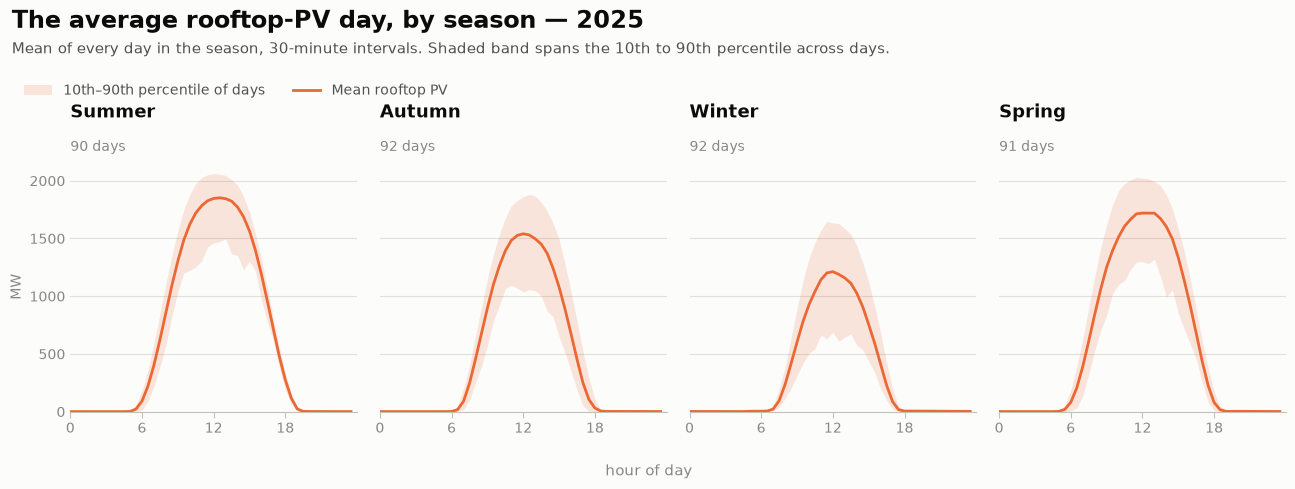

        mean daily peak (MW)  mean daily energy (GWh)
season                                               
Summer               1890.56                    15.30
Autumn               1591.49                    10.64
Winter               1302.22                     7.61
Spring               1784.83                    13.57


In [8]:
# ── Chart 1: average day shape by season ────────────────────────────────
SEASON_ORDER = ["Summer", "Autumn", "Winter", "Spring"]
MIN_DAYS = 30          # below this, an "average day" is not meaningful

days = d30.groupby("season")["date"].nunique()
seasons = [s for s in SEASON_ORDER if days.get(s, 0) >= MIN_DAYS]
print("days per season:", days.to_dict())
print("plotted:", seasons, " dropped:", [s for s in SEASON_ORDER if s not in seasons])

# Mean plus a 10th-90th percentile band, taken across the days of each season.
prof = (d30.groupby(["season", "tod_min"])["dpv_mw"]
        .agg(mean="mean",
             p10=lambda s: s.quantile(0.10),
             p90=lambda s: s.quantile(0.90))
        .reset_index())

fig, axes = plt.subplots(1, len(seasons), figsize=(13, 4.9), sharey=True)
axes = np.atleast_1d(axes)

for i, (ax, s) in enumerate(zip(axes, seasons)):
    p = prof[prof.season == s].sort_values("tod_min")
    hrs = p.tod_min / 60
    # Upper edge first, then the lower edge filled back up to it, so the fill
    # lands strictly between the two percentiles.
    ax.fill_between(hrs, p.p10, p.p90, color=ORANGE, alpha=0.16, linewidth=0,
                     label="10th–90th percentile of days" if i == 0 else None)
    ax.plot(hrs, p["mean"], color=ORANGE, linewidth=2,
            label="Mean rooftop PV" if i == 0 else None)
    ax.set_xlim(0, 24)
    ax.set_xticks([0, 6, 12, 18])
    # Panel title, stacked: season name bold/ink, day count smaller/muted.
    ax.text(0, 1.16, s, transform=ax.transAxes, ha="left", va="bottom",
            fontsize=13, fontweight="bold", color=INK)
    ax.text(0, 1.03, f"{days[s]} days", transform=ax.transAxes, ha="left", va="bottom",
            fontsize=10, color=MUTED)

axes[0].set_ylim(bottom=0)
axes[0].set_ylabel("MW", color=MUTED)

fig.subplots_adjust(top=0.66, bottom=0.15, left=0.055, right=0.99, wspace=0.08)

# Shared legend for all panels, built once from panel 1's handles so it stays
# centred at any panel count -- placed between the subtitle and the panel titles.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.01, 0.845),
           bbox_transform=fig.transFigure, ncol=2, frameon=False,
           labelcolor=INK_2, fontsize=10)

# One centred axis label rather than one per panel, so it stays centred at any panel count
fig.text(0.5, 0.02, "hour of day", ha="center", color=MUTED, fontsize=11)

style(fig, axes, f"The average rooftop-PV day, by season — {YEAR}",
      "Mean of every day in the season, 30-minute intervals. "
      "Shaded band spans the 10th to 90th percentile across days.",
      title_y=0.97, subtitle_y=0.905)
plt.show()

# The numbers behind the shapes.
by_season = (d30.groupby(["season", "date"])["dpv_mw"]
             .agg(peak="max", energy=lambda s: s.sum() / 2 / 1000)   # 30-min MW -> GWh
             .reset_index().groupby("season")[["peak", "energy"]].mean()
             .reindex(seasons).round(2))
by_season.columns = ["mean daily peak (MW)", "mean daily energy (GWh)"]
print(by_season)

### 2. One week, at full 5-minute resolution

The seasonal means above are smooth. Real rooftop PV is not — and the averaging is exactly what
hides that. This keeps every 5-minute reading and narrows the window to a week.

`ANCHOR` is 9 April 2025, the most volatile day in the record and the day that happens to hold the
year's highest instantaneous reading (2,289 MW). Broken cloud, not clear sky, sets the annual peak:
cloud-edge enhancement pushes output above what a clear day reaches, while the day's *energy* total
(11.3 GWh) is well below a clear December day's ~17.5 GWh. Change `ANCHOR` to look at another week —
`2025-12-21` is the highest-energy day of the year, `2025-08-02` the lowest.

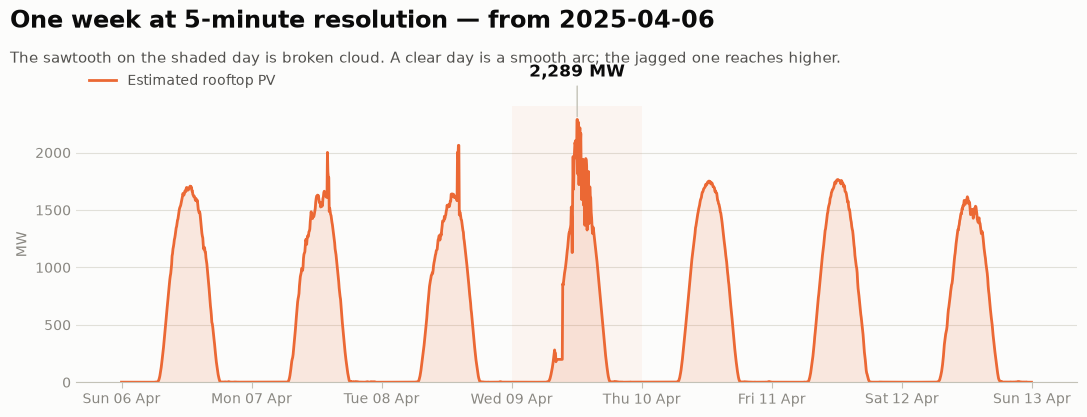

            peak (MW)  energy (GWh)  total 5-min movement (MW)
date                                                          
2025-04-06     1708.5          11.8                     3662.0
2025-04-07     2001.8          11.5                     4784.6
2025-04-08     2063.3          11.2                     4707.0
2025-04-09     2289.3          11.3                    13042.1
2025-04-10     1752.6          12.1                     3609.5
2025-04-11     1765.9          11.9                     3679.8
2025-04-12     1615.3          10.8                     3876.8


In [9]:
# ── Chart 2: one week in 5-minute detail ─────────────────────────────────
ANCHOR = pd.Timestamp("2025-04-09")     # most volatile day of 2025; also its highest 5-min reading
start  = ANCHOR - pd.Timedelta(days=3)
wk = d05[(d05.ts >= start) & (d05.ts < start + pd.Timedelta(days=7))]

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.fill_between(wk.ts, 0, wk.dpv_mw, color=ORANGE, alpha=0.14, linewidth=0)
ax.plot(wk.ts, wk.dpv_mw, color=ORANGE, linewidth=2, label="Estimated rooftop PV")

# Mark the anchor day so the contrast with its neighbours is findable, not hunted for.
ax.axvspan(ANCHOR, ANCHOR + pd.Timedelta(days=1), color=ORANGE, alpha=0.05, linewidth=0)
pk = wk.loc[wk.dpv_mw.idxmax()]
ax.annotate(f"{pk.dpv_mw:,.0f} MW", xy=(pk.ts, pk.dpv_mw), xytext=(0, 28),
            textcoords="offset points", ha="center", va="bottom",
            color=INK, fontsize=12, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=AXIS, lw=1))

ax.set_ylim(bottom=0)
ax.set_ylabel("MW", color=MUTED)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))

fig.subplots_adjust(top=0.74, bottom=0.14, left=0.07, right=0.98)
style(fig, ax, f"One week at 5-minute resolution — from {start.date()}",
      "The sawtooth on the shaded day is broken cloud. A clear day is a smooth arc; "
      "the jagged one reaches higher.",
      legend_ax=ax, legend_ncol=1, title_y=0.95, subtitle_y=0.86)
plt.show()

# Quantify the difference the eye is picking up: total absolute 5-minute movement per day.
wk_var = (wk.assign(ramp=wk.dpv_mw.diff().abs())
          .groupby("date").agg(**{"peak (MW)": ("dpv_mw", "max"),
                                  "energy (GWh)": ("dpv_mw", lambda s: s.sum() / 12 / 1000),
                                  "total 5-min movement (MW)": ("ramp", "sum")}).round(1))
print(wk_var)

### 3. Carpet plots — every interval of the year at once

No aggregation, no window: one column per day, one row per time of day, magnitude as colour.
The solar day's envelope draws itself — the lit block narrows into winter and widens back out —
and each pale vertical scar is a cloudy day.

The second carpet swaps the measure for **volatility**: the mean absolute 5-minute change in each
half hour. It is a map of where the forecasting problem lives, and it is emphatically *not* where
output is highest. Two structures show up that the output carpet cannot show:

- **Two dark bands track sunrise and sunset**, not midday. The steepest 5-minute movement is the
  geometric ramp at the edges of the solar day, and it happens on clear days and cloudy ones alike.
- **Midday darkens in winter and pales in summer** — the reverse of the output carpet. Summer
  middays are reliably clear, so nothing moves; winter middays are where cloud actually bites.

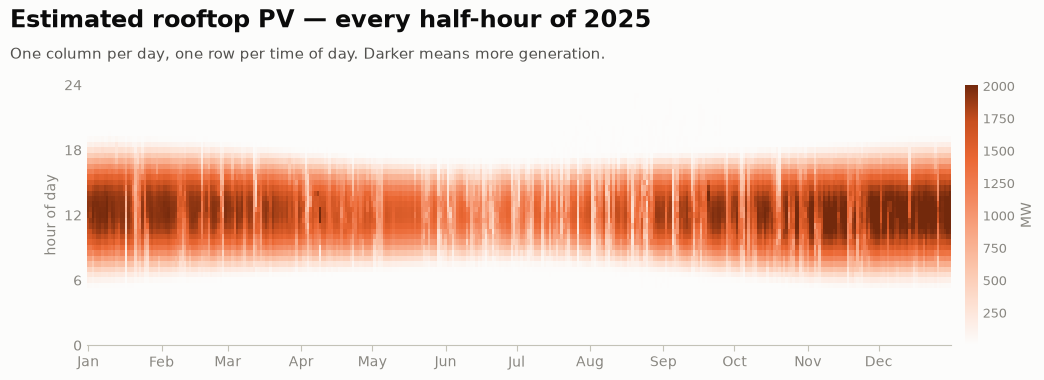

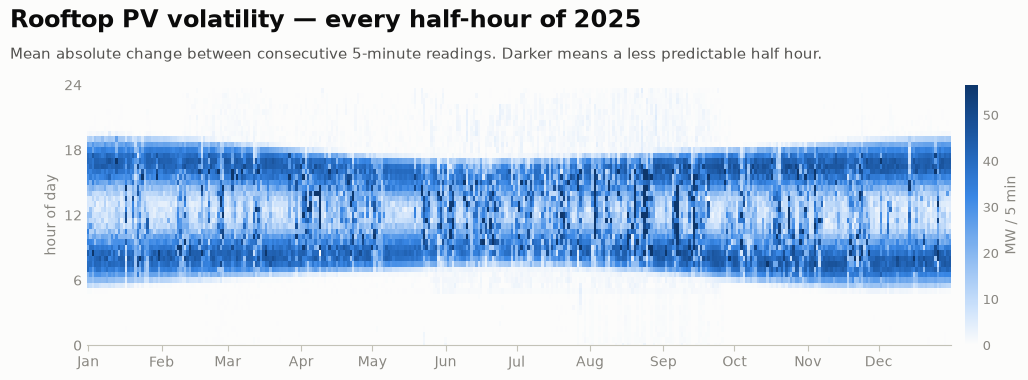

In [10]:
# ── Chart 3: carpet plots ──────────────────────────────────────
def to_surface(ramp):
    """Anchor a single-hue ramp's zero end on the chart surface.

    Half of a solar carpet is night. Left alone, the ramp's lightest step paints
    every zero a visible tint and the plot spends ink on nothing -- the demand
    carpets never hit this because demand has no zeros. Blending the low end into
    the surface lets night recede so the lit envelope draws itself.
    """
    return LinearSegmentedColormap.from_list("surface_ramp", [SURFACE] + list(ramp))


def carpet(frame, col, title, subtitle, ramp, transform=None, unit="MW", figsize=(11, 4.2)):
    v = frame[col] if transform is None else transform(frame[col])
    piv = (frame.assign(_v=v)
           .pivot_table(index="tod_min", columns="date", values="_v", aggfunc="mean")
           .sort_index())
    # Clip the colour range to the 1st-99th percentile: a handful of extreme
    # intervals otherwise compress the ramp and wash out the daily structure.
    lo, hi = np.nanpercentile(piv.values.astype(float), [1, 99])
    dates = pd.to_datetime(piv.columns)
    hours = piv.index / 60

    fig, ax = plt.subplots(figsize=figsize)
    mesh = ax.pcolormesh(dates, hours, piv.values, cmap=to_surface(ramp),
                          vmin=lo, vmax=hi, shading="auto")
    cbar = fig.colorbar(mesh, ax=ax, pad=0.015, fraction=0.05)
    cbar.set_label(unit, color=MUTED, fontsize=10)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(colors=MUTED, length=0, labelsize=9)

    ax.set_ylim(0, 24)
    ax.set_yticks([0, 6, 12, 18, 24])
    ax.set_ylabel("hour of day", color=MUTED)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    fig.subplots_adjust(top=0.76, bottom=0.14, left=0.08, right=0.92)
    style(fig, ax, title, subtitle, title_y=0.94, subtitle_y=0.85)
    ax.grid(False)   # heatmap covers the full plot area; gridlines would just draw over it
    return fig, ax


carpet(d30, "dpv_mw",
       f"Estimated rooftop PV — every half-hour of {YEAR}",
       "One column per day, one row per time of day. Darker means more generation.",
       RAMP_ORANGE)
plt.show()

# Volatility: mean absolute 5-minute change, averaged into each half hour.
vol = (d05.assign(ramp=d05.dpv_mw.diff().abs())
       .set_index("ts")["ramp"].resample("30min", label="left", closed="left").mean()
       .reset_index())
vol = add_time_parts(vol)

carpet(vol, "ramp",
       f"Rooftop PV volatility — every half-hour of {YEAR}",
       "Mean absolute change between consecutive 5-minute readings. "
       "Darker means a less predictable half hour.",
       RAMP_BLUE, unit="MW / 5 min")
plt.show()

### 4. What rooftop PV does to grid demand

Everything above treats rooftop PV as a series in its own right. It only becomes interesting next to
the demand it displaces.

Operational demand is measured at the grid, so it is already *net* of rooftop PV. Adding the two back
together approximates the underlying consumer load:

```
underlying demand ≈ unscheduled operational demand + estimated rooftop PV
```

**Stated assumption, and it is approximate.** Operational demand includes transmission and
distribution losses; rooftop PV serves load behind the meter without incurring them, so the sum
slightly overstates true underlying demand. Unscheduled operational demand is used rather than
operational demand so that grid-scale battery charging stays out of the picture (see the demand
notebook's identity check).

The window plotted is the mild spring weekend of 15–16 November 2025, which holds 2025's minimum
grid demand — and which day *wins* depends on the resolution you ask at:

| | 15 Nov (Sat) | 16 Nov (Sun) | annual minimum |
|---|---|---|---|
| 5-minute | **378.9 MW** 12:45 | 379.2 MW 11:05 | 15 Nov |
| 30-minute | 394.4 MW 12:30 | **385.9 MW** 11:00 | 16 Nov |

The two days are tied to within 0.2 MW at 5-minute resolution. Saturday's dip is the deeper but
narrower one, so the half-hour mean clips it harder and Sunday takes the record instead — which is
why the demand notebook, working at 30 minutes, reports 386 MW on 16 November. Neither is wrong.
**Always quote the resolution alongside a minimum-demand record**; at these margins it decides the
answer.

minimum unscheduled demand 2025: 379 MW at 2025-11-15 12:45:00
  rooftop PV at that moment: 2,026 MW
  share of underlying demand met by rooftop PV: 84.2%


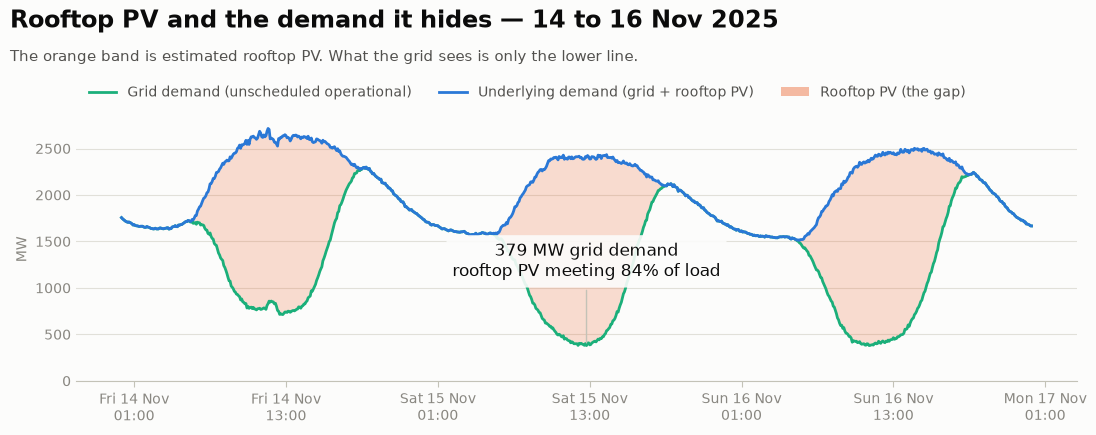

In [11]:
# ── Chart 4: rooftop PV against the demand it hides ──────────────
from wa_data import load_demand

dem = load_demand(raw='../data/raw')
both = add_time_parts(dem.merge(df, on="ts", how="inner"))
both["underlying_mw"] = both.unscheduled_demand_mw + both.dpv_mw   # STATED ASSUMPTION, see above
byr = both[both.year == YEAR]

# The minimum-grid-demand interval of the year, and the day it falls on.
lo = byr.loc[byr.unscheduled_demand_mw.idxmin()]
MIN_DAY = lo.date
print(f"minimum unscheduled demand {YEAR}: {lo.unscheduled_demand_mw:,.0f} MW at {lo.ts}")
print(f"  rooftop PV at that moment: {lo.dpv_mw:,.0f} MW")
print(f"  share of underlying demand met by rooftop PV: {lo.dpv_mw / lo.underlying_mw:.1%}")

win_start = MIN_DAY - pd.Timedelta(days=1)
dayw = byr[(byr.ts >= win_start) & (byr.ts < win_start + pd.Timedelta(days=3))]

fig, ax = plt.subplots(figsize=(11, 4.7))
# The fill between the two lines IS the rooftop PV series.
ax.fill_between(dayw.ts, dayw.unscheduled_demand_mw, dayw.underlying_mw,
                 color=ORANGE, alpha=0.22, linewidth=0)
ax.plot(dayw.ts, dayw.unscheduled_demand_mw, color=AQUA, linewidth=2,
        label="Grid demand (unscheduled operational)")
ax.plot(dayw.ts, dayw.underlying_mw, color=BLUE, linewidth=2,
        label="Underlying demand (grid + rooftop PV)")
# Legend proxy for the filled band, so the orange area is named rather than inferred.
gap_proxy = Patch(facecolor=ORANGE, alpha=0.45, label="Rooftop PV (the gap)")

# Label sits ABOVE the trough, inside the band: below it would land on the axis
# tick labels. The surface-coloured backing keeps it legible over the fill.
ax.annotate(
    f"{lo.unscheduled_demand_mw:,.0f} MW grid demand\n"
    f"rooftop PV meeting {lo.dpv_mw / lo.underlying_mw:.0%} of load",
    xy=(lo.ts, lo.unscheduled_demand_mw), xytext=(0, 46), textcoords="offset points",
    ha="center", va="bottom", color=INK, fontsize=12,
    arrowprops=dict(arrowstyle="-", color=AXIS, lw=1),
    bbox=dict(facecolor=SURFACE, alpha=0.9, edgecolor="none", boxstyle="round,pad=0.35"))

ax.set_ylim(bottom=0)
ax.set_ylabel("MW", color=MUTED)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b\n%H:%M"))

fig.subplots_adjust(top=0.72, bottom=0.16, left=0.07, right=0.98)
style(fig, ax, "Rooftop PV and the demand it hides — "
              f"{win_start:%d} to {win_start + pd.Timedelta(days=2):%d %b %Y}",
      "The orange band is estimated rooftop PV. What the grid sees is only the lower line.",
      title_y=0.95, subtitle_y=0.865)

handles, labels = ax.get_legend_handles_labels()
handles.append(gap_proxy); labels.append("Rooftop PV (the gap)")
ax.legend(handles, labels, loc="lower left", bbox_to_anchor=(0, 1.02), ncol=3,
          frameon=False, labelcolor=INK_2)
plt.show()

In [12]:
# Same relationship at annual scale, so the single day above is not mistaken for the norm.
share_year = byr.dpv_mw.sum() / byr.underlying_mw.sum()
print(f"{YEAR} rooftop PV energy:        {byr.dpv_mw.sum() / 12 / 1000:>9,.0f} GWh")
print(f"{YEAR} underlying demand energy: {byr.underlying_mw.sum() / 12 / 1000:>9,.0f} GWh")
print(f"{YEAR} rooftop PV share of underlying demand: {share_year:.1%}")

midday = byr[(byr.tod_min >= 660) & (byr.tod_min <= 780)]        # 11:00-13:00
print("\nmean midday share of underlying demand met by rooftop PV, by season:")
print((midday.groupby("season")
       .apply(lambda g: g.dpv_mw.sum() / g.underlying_mw.sum(), include_groups=False)
       .reindex(seasons).map("{:.1%}".format)).to_string())

2025 rooftop PV energy:            4,291 GWh
2025 underlying demand energy:    21,955 GWh
2025 rooftop PV share of underlying demand: 19.5%

mean midday share of underlying demand met by rooftop PV, by season:
season
Summer    53.6%
Autumn    52.8%
Winter    41.9%
Spring    63.1%
